In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



1. Classification task
Whether its going to be a up day or not
2. Read the dataset

In [3]:
data = pd.read_csv("MLT01_data_TSLA.csv", parse_dates=True, index_col=0)
df = data.copy()
df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2013-12-31,152.320007,153.199997,148.660004,150.429993,150.429993,4262400
2014-01-02,149.800003,152.479996,146.550003,150.100006,150.100006,6188400
2014-01-03,150.000000,152.190002,148.600006,149.559998,149.559998,4695000
2014-01-06,150.000000,150.399994,145.240005,147.000000,147.000000,5361100
2014-01-07,147.619995,150.399994,145.250000,149.360001,149.360001,5034100


3. Generate Target Value
If tomorrows return is > 0 then 1 else 0

In [4]:
df['returns'] = np.log(df['Adj Close']/df['Adj Close'].shift(1))
df['target_value'] = np.where(df['returns'].shift(-1)> 0,1,0)
df.target_value.value_counts()
df.head()

,Open,High,Low,Close,Adj Close,Volume,returns,target_value
Date,,,,,,,,
2013-12-31,152.320007,153.199997,148.660004,150.429993,150.429993,4262400,NaN,0
2014-01-02,149.800003,152.479996,146.550003,150.100006,150.100006,6188400,-0.002196,0
2014-01-03,150.000000,152.190002,148.600006,149.559998,149.559998,4695000,-0.003604,0
2014-01-06,150.000000,150.399994,145.240005,147.000000,147.000000,5361100,-0.017265,1
2014-01-07,147.619995,150.399994,145.250000,149.360001,149.360001,5034100,0.015927,1


4. Feature selection/extraction

In [5]:
features_list = []
# rolling std
for i in range(5,20,5):
    col_names = f"std_{i}"
    df[col_names] = df['returns'].rolling(window = i).std()
    features_list.append(col_names)
    
# rolling mean
for i in range(10,30,5):
    col_names = f"mean_{i}"
    df[col_names] = df['returns'].rolling(window = i).mean()
    features_list.append(col_names)
    
# Rolling percentage change
for i in range(3,12,3):
    col_names = f"pct_{i}"
    df[col_names] = df['Close'].pct_change().rolling(window=i).sum()
    features_list.append(col_names)
    
# Rolling Volume
col_names = 'vol_4'
df[col_names] = df['Volume'].rolling(window = 4).mean()
features_list.append(col_names) 

# Close-Open 
col_names = 'co'
df[col_names] = df['Close'] - df['Open']
features_list.append(col_names) 
 
features_list   
    

['std_5',
 'std_10',
 'std_15',
 'mean_10',
 'mean_15',
 'mean_20',
 'mean_25',
 'pct_3',
 'pct_6',
 'pct_9',
 'vol_4',
 'co']

In [6]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1510 entries, 2013-12-31 to 2019-12-30
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1510 non-null   float64
 1   High          1510 non-null   float64
 2   Low           1510 non-null   float64
 3   Close         1510 non-null   float64
 4   Adj Close     1510 non-null   float64
 5   Volume        1510 non-null   int64  
 6   returns       1509 non-null   float64
 7   target_value  1510 non-null   int32  
 8   std_5         1505 non-null   float64
 9   std_10        1500 non-null   float64
 10  std_15        1495 non-null   float64
 11  mean_10       1500 non-null   float64
 12  mean_15       1495 non-null   float64
 13  mean_20       1490 non-null   float64
 14  mean_25       1485 non-null   float64
 15  pct_3         1507 non-null   float64
 16  pct_6         1504 non-null   float64
 17  pct_9         1501 non-null   float64
 18  vol_4     

,Open,High,Low,Close,Adj Close,Volume,returns,target_value,std_5,std_10,std_15,mean_10,mean_15,mean_20,mean_25,pct_3,pct_6,pct_9,vol_4,co
Date,,,,,,,,,,,,,,,,,,,,
2013-12-31,152.320007,153.199997,148.660004,150.429993,150.429993,4262400,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.890015
2014-01-02,149.800003,152.479996,146.550003,150.100006,150.100006,6188400,-0.002196,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.300003
2014-01-03,150.000000,152.190002,148.600006,149.559998,149.559998,4695000,-0.003604,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.440002
2014-01-06,150.000000,150.399994,145.240005,147.000000,147.000000,5361100,-0.017265,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.022908,NaN,NaN,5126725.0,-3.000000
2014-01-07,147.619995,150.399994,145.250000,149.360001,149.360001,5034100,0.015927,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004660,NaN,NaN,5319650.0,1.740005


In [7]:
df.isna().sum()

Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
returns          1
target_value     0
std_5            5
std_10          10
std_15          15
mean_10         10
mean_15         15
mean_20         20
mean_25         25
pct_3            3
pct_6            6
pct_9            9
vol_4            3
co               0
dtype: int64

In [8]:
df.dropna()

,Open,High,Low,Close,Adj Close,Volume,returns,target_value,std_5,std_10,std_15,mean_10,mean_15,mean_20,mean_25,pct_3,pct_6,pct_9,vol_4,co
Date,,,,,,,,,,,,,,,,,,,,
2014-02-06,176.300003,180.110001,176.000000,178.380005,178.380005,5841600,0.022450,1,0.020603,0.031251,0.029174,-0.001734,0.005550,0.008239,0.006817,0.007736,0.019641,0.025104,6140200.0,2.080002
2014-02-07,181.009995,186.630005,179.600006,186.529999,186.529999,8928500,0.044676,1,0.029997,0.031405,0.029522,0.006609,0.005807,0.011728,0.008692,0.044278,0.021901,0.099315,6681100.0,5.520004
2014-02-10,189.339996,199.300003,189.320007,196.559998,196.559998,12970700,0.052376,1,0.030621,0.031704,0.031639,0.014741,0.009674,0.014964,0.010931,0.122164,0.083493,0.101442,8752200.0,7.220001
2014-02-11,198.970001,202.199997,192.699997,196.619995,196.619995,10709900,0.000305,0,0.031698,0.029318,0.030677,0.009736,0.007129,0.017218,0.011634,0.099766,0.107502,0.119406,9612675.0,-2.350006
2014-02-12,195.779999,198.270004,194.320007,195.320007,195.320007,5173700,-0.006634,1,0.026104,0.028348,0.030860,0.010854,0.005981,0.009578,0.010731,0.047465,0.091743,0.069366,9445700.0,-0.459991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-23,411.779999,422.010010,410.000000,419.220001,419.220001,13319600,0.033053,1,0.019137,0.020956,0.019988,0.021083,0.014977,0.011507,0.006971,0.065141,0.160407,0.187676,15075100.0,7.440002
2019-12-24,418.359985,425.470001,412.690002,425.250000,425.250000,8054700,0.014281,1,0.013697,0.020941,0.019758,0.019806,0.015665,0.011728,0.007791,0.051825,0.110308,0.190994,13558525.0,6.890015
2019-12-26,427.910004,433.480011,426.350006,430.940002,430.940002,10633900,0.013292,0,0.011723,0.020847,0.018525,0.020035,0.017182,0.013508,0.007248,0.061370,0.130268,0.184585,11690225.0,3.029999


In [9]:
df[features_list+['target_value']].head()

,std_5,std_10,std_15,mean_10,mean_15,mean_20,mean_25,pct_3,pct_6,pct_9,vol_4,co,target_value
Date,,,,,,,,,,,,,
2013-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.890015,0
2014-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.300003,0
2014-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.440002,0
2014-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.022908,NaN,NaN,5126725.0,-3.000000,1
2014-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004660,NaN,NaN,5319650.0,1.740005,1


In [10]:
df = df.dropna()

Generate Train Test split data

In [11]:
X_train,X_test,y_train,y_test = train_test_split(df[features_list][:-1],
                 df.iloc[:-1]['target_value'],
                 test_size = 0.25,
                 shuffle = False)

In [12]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1113, 12), (371, 12), (1113,), (371,))

In [13]:
X_train.columns

Index(['std_5', 'std_10', 'std_15', 'mean_10', 'mean_15', 'mean_20', 'mean_25',
       'pct_3', 'pct_6', 'pct_9', 'vol_4', 'co'],
      dtype='object')

c:\Users\HaikuJAM02102021\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


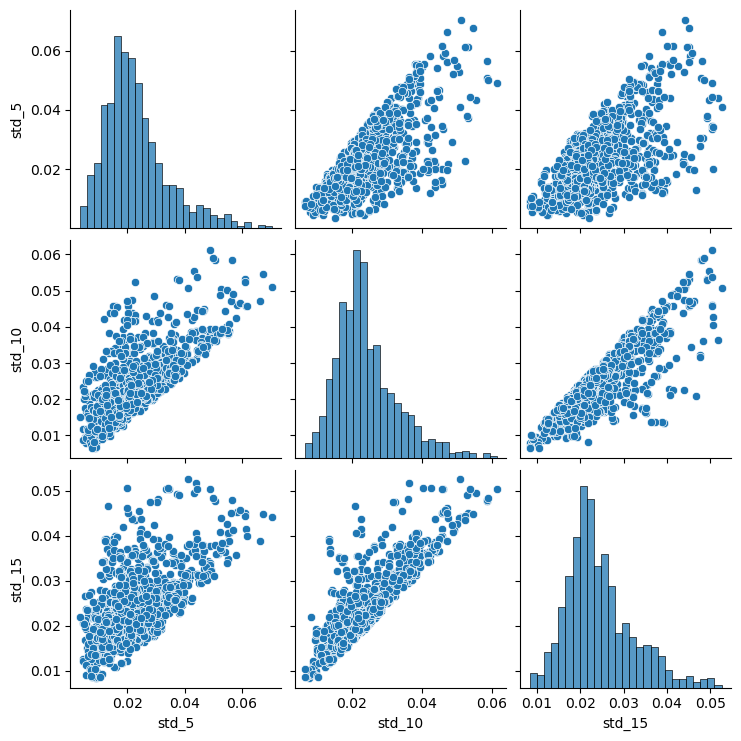

In [14]:
sns.pairplot(X_train[['std_5', 'std_10', 'std_15']])

From the above plot, we can see they are not normalized
Hence we need to prform Feature Scaling

In [15]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

c:\Users\HaikuJAM02102021\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


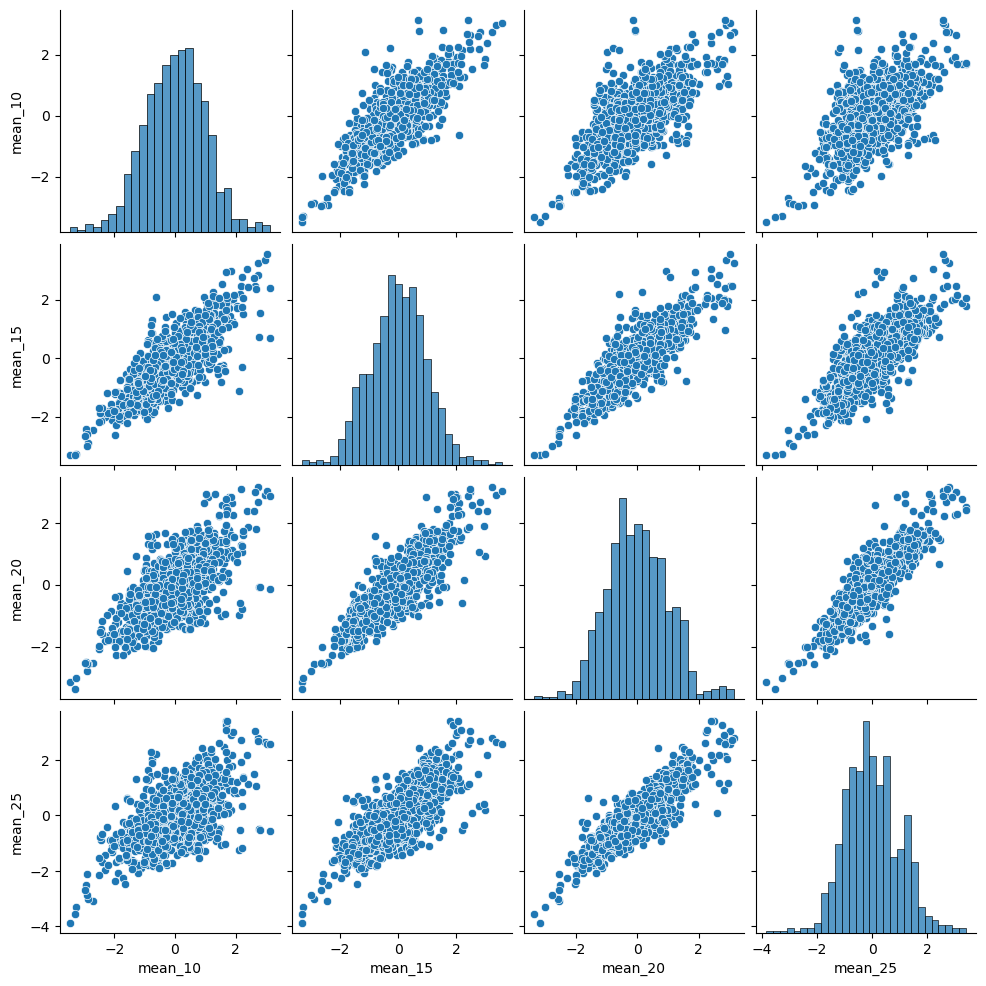

In [16]:
X_train_scaled_df = pd.DataFrame( X_train_scaled,columns = X_train.columns) # Make sure the X_train_scaled is a dataframe
sns.pairplot(X_train_scaled_df[['mean_10', 'mean_15', 'mean_20', 'mean_25']])

From the plot above the feature are all scaled and now ready to be fed to the model to predict the data

In [17]:
X_train_scaled_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
std_5,1113.0,-0.0,1.0,-1.76,-0.67,-0.18,0.46,4.30
std_10,1113.0,0.0,1.0,-1.98,-0.69,-0.18,0.48,4.23
std_15,1113.0,0.0,1.0,-2.06,-0.66,-0.22,0.46,3.62
mean_10,1113.0,0.0,1.0,-3.48,-0.68,0.03,0.69,3.14
mean_15,1113.0,-0.0,1.0,-3.31,-0.66,0.04,0.65,3.58
mean_20,1113.0,-0.0,1.0,-3.37,-0.68,-0.04,0.68,3.16
mean_25,1113.0,-0.0,1.0,-3.86,-0.71,-0.08,0.61,3.40
pct_3,1113.0,0.0,1.0,-4.07,-0.56,-0.00,0.60,4.25
pct_6,1113.0,-0.0,1.0,-4.29,-0.65,0.02,0.65,4.22
pct_9,1113.0,-0.0,1.0,-3.48,-0.67,0.02,0.65,3.57


## Define, Train and Predict the model

In [18]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state = 1)

In [19]:
model.fit(X_train_scaled,y_train)

LogisticRegression(random_state=1)

In [21]:
#model prediction
y_pred_train = model.predict(X_train_scaled)
train_score = model.score(X_train_scaled,y_train)
train_score

0.5354896675651393

In [22]:
y_pred_test = model.predict(X_test_scaled)
test_score = model.score(X_test_scaled,y_test)
test_score

0.5040431266846361

In [26]:
# Another way to calculate the score

from sklearn.metrics import accuracy_score

print(f"Accuracy_score on training data is {accuracy_score(y_train,y_pred_train)}")
print(f"Accuracy score on test data is {accuracy_score(y_test,y_pred_test)}")

Accuracy_score on training data is 0.5354896675651393
Accuracy score on test data is 0.5040431266846361


In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred_test)
cm

array([[ 32, 155],
       [ 29, 155]], dtype=int64)

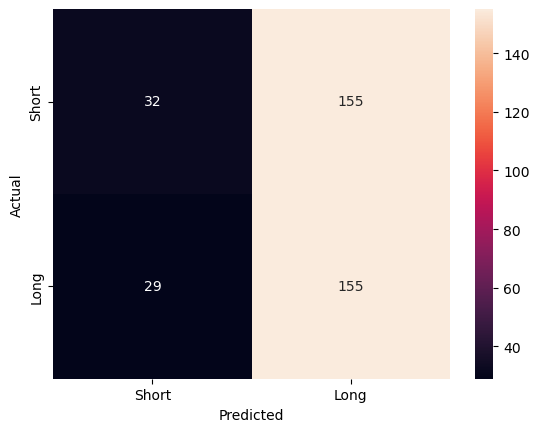

In [37]:
# plot the confusion matrix in a heatmap
df = pd.DataFrame(cm,index = ['Short','Long'],columns = ['Short','Long'])
sns.heatmap(df,annot= True,fmt='g')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [39]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.52      0.17      0.26       187
           1       0.50      0.84      0.63       184

    accuracy                           0.50       371
   macro avg       0.51      0.51      0.44       371
weighted avg       0.51      0.50      0.44       371

